This is a tensorflow model that classifies gas from chemical sensor reading.The input of the model is collected from 16 different chemical gas sensors. The gases are classified into 1 among 6 gases which are:
1.   Ethanol
2.   Ethylene
1.   Ammonia
2.   Acetaldehyde
1.   Acetene
2.   Toluene

**Electronic Nose** : System that uses multiple sensors to detect chemicals in air.

Each gas has 128 input features from 16 sensors where each sensor give us 8 extracted values.

The dataset is collected over a span of 36 months , and 10 time based batches with 13,910 total gas measurements.

Challenges we face: Sensor drift - A sensor may slowly gradually change due to aging , temerature or other environmental factors.Due to this, model will be trained on old sensor patterns and will be able to classify based on new sensor data. So , I have split the data based on time rather than random split.

Train data : 1 - 7 batches.

Validation data : 8 batch.

Test data : 9 and 10 batches.

I will also measure the overall classification accuracy and also check performance of each gas in each time batch.

In [2]:
import os
os.listdir('/content/drive/MyDrive/scent-shift')

'''Metadata
- Dataset: Gas Sensor Array Drift Dataset
- Source: UCI Machine Learning Repository
- Samples: 13,910
- Sensors: 16
- Features per sample: 128
- Classes: 6
- Batches: 10
- Split: batches 1-7 train, 8 validation, 9-10 test'''

['batch5.dat',
 'batch3.dat',
 'batch10.dat',
 'batch9.dat',
 'batch6.dat',
 'batch8.dat',
 'batch2.dat',
 'batch4.dat',
 'batch7.dat',
 'batch1.dat']

In [13]:
#required libraries
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix , classification_report

In [16]:
def parse(file , n_features = 128):
  X = []
  y = []

  with open(file, "r") as f:
    for line in f:
      line = line.strip()
      if not line:
        continue

      parts = line.split()
      label = int(parts[0]) - 1
      features = np.zeros(n_features , dtype = np.float32)

      for item in parts[1:]:
        idx , val = item.split(":")
        features[int(idx) - 1] = float(val)

      X.append(features)
      y.append(label)

  return np.array(X , dtype = np.float32) , np.array (y , dtype = np.int32)

In [17]:
base_dir = '/content/drive/MyDrive/scent-shift'

X_batches = []
y_batches = []

for i in range(1,11):
  file_path = os.path.join(base_dir , f"batch{i}.dat")

  X , y = parse(file_path)

  X_batches.append(X)
  y_batches.append(y)

  print(f"{i} batch , X = {X.shape} , y = {y.shape}")

1 batch , X = (445, 128) , y = (445,)
2 batch , X = (1244, 128) , y = (1244,)
3 batch , X = (1586, 128) , y = (1586,)
4 batch , X = (161, 128) , y = (161,)
5 batch , X = (197, 128) , y = (197,)
6 batch , X = (2300, 128) , y = (2300,)
7 batch , X = (3613, 128) , y = (3613,)
8 batch , X = (294, 128) , y = (294,)
9 batch , X = (470, 128) , y = (470,)
10 batch , X = (3600, 128) , y = (3600,)


In [18]:
X_train = np.vstack(X_batches[:7])
y_train = np.concatenate(y_batches[:7])

X_validate = X_batches[7]
y_validate = y_batches[7]

X_test = np.vstack(X_batches[8:])
y_test = np.concatenate(y_batches[8:])

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) #fit_transform is used only where the model has to learn
X_validate_scaled = scaler.transform(X_validate)
X_test_scaled = scaler.transform(X_test)

In [20]:
ss_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,)),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(32,activation="relu"),
    tf.keras.layers.Dense(6,activation="softmax")
])

ss_model.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy,
    metrics = ["Accuracy"]
)

Early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True
)

ss_history = ss_model.fit(
    X_train_scaled , y_train,
    epochs = 25,
    batch_size = 32,
    validation_data = (X_validate_scaled , y_validate),
    callbacks = [Early_stopping]
)

Epoch 1/25
299/299 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - Accuracy: 0.9067 - loss: 0.4028 - val_Accuracy: 0.8912 - val_loss: 0.7397
Epoch 2/25
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.9854 - loss: 0.0936 - val_Accuracy: 0.9218 - val_loss: 0.6392
Epoch 3/25
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.9873 - loss: 0.0701 - val_Accuracy: 0.9286 - val_loss: 0.5730
Epoch 4/25
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.9887 - loss: 0.0496 - val_Accuracy: 0.6973 - val_loss: 0.7068
Epoch 5/25
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.9926 - loss: 0.0349 - val_Accuracy: 0.9218 - val_loss: 0.4190
Epoch 6/25
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.9940 - loss: 0.0283 - val_Accuracy: 0.9286 - val_loss: 0.3619
Epoch 7/25
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.9932 - loss: 0.0305 - val_Accuracy: 0.9320 - val_loss: 0.4052
Epoch 8/25
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.9949 - loss: 0.0235 - val_Accuracy: 0

In [21]:
y_pred_prob = ss_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob , axis = 1)

cm = confusion_matrix(y_test , y_pred)
print(cm)

print(classification_report(y_test , y_pred))

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[403   0   2  62  30 164]
 [  3 557  24   4  66   1]
 [ 11   3 678   6   2   0]
 [ 33   1   0 328   3 310]
 [  0   0   7  36 550  85]
 [ 20   0   0 184   4 493]]
              precision    recall  f1-score   support

           0       0.86      0.61      0.71       661
           1       0.99      0.85      0.92       655
           2       0.95      0.97      0.96       700
           3       0.53      0.49      0.51       675
           4       0.84      0.81      0.83       678
           5       0.47      0.70      0.56       701

    accuracy                           0.74      4070
   macro avg       0.77      0.74      0.75      4070
weighted avg       0.77      0.74      0.75      4070



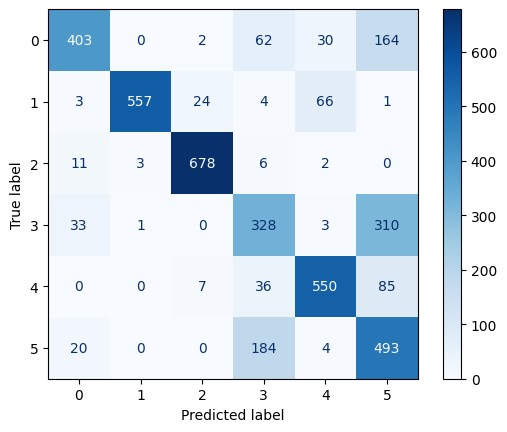

In [22]:
mat_disp = ConfusionMatrixDisplay(confusion_matrix = cm)
mat_disp.plot(cmap = "Blues")
plt.show()